Train size: (40000, 76) Test size: (10000, 76)

Model Accuracy: 0.7208

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.72      0.78      7110
           1       0.51      0.73      0.60      2890

    accuracy                           0.72     10000
   macro avg       0.69      0.72      0.69     10000
weighted avg       0.77      0.72      0.73     10000



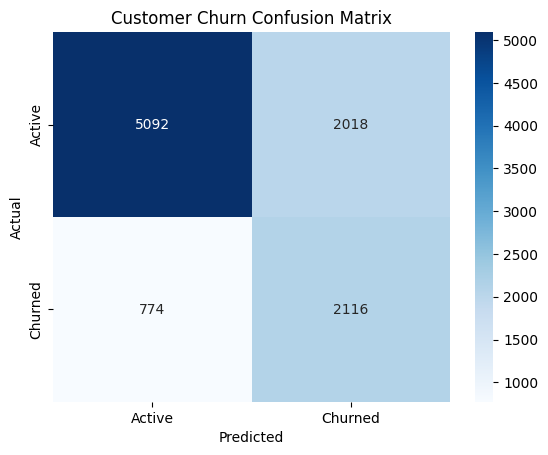


Top 10 Features Driving Churn:

                     Feature  Coefficient
18            Lifetime_Value     0.794423
13    Customer_Service_Calls     0.593944
5      Cart_Abandonment_Rate     0.552703
9   Days_Since_Last_Purchase     0.364342
24                 High_Risk     0.314537
2            Login_Frequency     0.237884
11              Returns_Rate     0.203188
33               Country_USA     0.068364
55            City_Melbourne     0.049642
37             City_Brisbane     0.046303

Top 10 Features Preventing Churn:

                    Feature  Coefficient
22       Purchase_Intensity    -0.027504
23            Recency_Score    -0.028777
6            Wishlist_Items    -0.030031
21         Engagement_Score    -0.037205
14  Product_Reviews_Written    -0.039730
4         Pages_Per_Session    -0.124580
12          Email_Open_Rate    -0.177367
10      Discount_Usage_Rate    -0.219744
7           Total_Purchases    -0.244786
0                       Age    -0.309628


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

# Load feature engineered dataset
df = pd.read_csv("../data/processed/feature_engineered_data.csv")

# Define Features (X) & Target (y)
# Drop target column from features
X = df.drop("Churned", axis=1)

# Target Variable
y = df["Churned"]

X = pd.get_dummies(X, drop_first=True)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Logistic Regression Model
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", round(accuracy, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Active", "Churned"],
            yticklabels=["Active", "Churned"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Customer Churn Confusion Matrix")
plt.show()

# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance = feature_importance.sort_values(by="Coefficient", ascending=False)

print("\nTop 10 Features Driving Churn:\n")
print(feature_importance.head(10))

print("\nTop 10 Features Preventing Churn:\n")
print(feature_importance.tail(10))

Train size: (40000, 76) Test size: (10000, 76)

Random Forest Accuracy: 0.9132

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7110
           1       0.92      0.77      0.84      2890

    accuracy                           0.91     10000
   macro avg       0.91      0.87      0.89     10000
weighted avg       0.91      0.91      0.91     10000



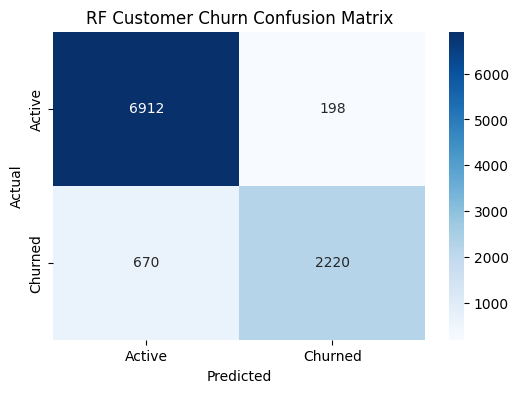


Top 10 Important Features:

                     Feature  Importance
13    Customer_Service_Calls    0.114201
18            Lifetime_Value    0.093438
5      Cart_Abandonment_Rate    0.076785
0                        Age    0.064447
21          Engagement_Score    0.057788
10       Discount_Usage_Rate    0.048809
8        Average_Order_Value    0.047365
7            Total_Purchases    0.036961
9   Days_Since_Last_Purchase    0.035793
12           Email_Open_Rate    0.033732


['../Models/model_features.pkl']

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load feature engineered dataset
df = pd.read_csv("../data/processed/feature_engineered_data.csv")

# Define Features (X) & Target (y)
# Drop target column from features
X = df.drop("Churned", axis=1)

# Target Variable
y = df["Churned"]

X = pd.get_dummies(X, drop_first=True)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

# Logistic Regression Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
accuracy = accuracy_score(y_test, y_pred_rf)

print("\nRandom Forest Accuracy:", round(accuracy, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Active", "Churned"],
            yticklabels=["Active", "Churned"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RF Customer Churn Confusion Matrix")
plt.show()

# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

print("\nTop 10 Important Features:\n")
print(feature_importance.head(10))

# Save model
joblib.dump(rf_model, "../Models/random_forest_churn_model.pkl")

# Save Preprocessing
joblib.dump(X.columns, "../Models/model_features.pkl")